<a href="https://colab.research.google.com/github/chitrangada-juneja/CSC480_HWS/blob/homeworks/HW2_480.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1: Paired T-test

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import t
import math

scores_A=np.array([3,4,3,2,4,5,4,2,3,4,1,2])
scores_B=np.array([1,3,3,2,2,3,5,2,2,1,2,1])

def compute_ci(data):
  data_len=len(data)
  mean=np.mean(data)
  confidence_interval=0.95
  standard_err= stats.sem(data)
  t_stat=stats.t.ppf((1+confidence_interval)/2,df=data_len-1) #to calculate critical t val
  margin_of_error=t_stat*standard_err

  return mean-margin_of_error,mean+margin_of_error


ci_A=compute_ci(scores_A)
ci_B=compute_ci(scores_B)

print(f"CI for A:{ci_A}")
print(f"CI for B:{ci_B}")


CI for A:(2.3434452353035717, 3.8232214313630952)
CI for B:(1.5268346967576174, 2.9731653032423826)


In [ ]:

# we use the differences of each rating round , and use it to manually
#calculate the mean, standard deviation, and use it to calculate the t-statistic
#using the formula =(mean of differences)/(std dev of diff / sqrt(n))
#where n is the number of samples



differences=scores_A-scores_B
mean_diff=np.mean(differences)
std_diff=np.std(differences,ddof=1)

diff_len=len(differences)
t_val=mean_diff/(std_diff/math.sqrt(diff_len)) #t statistic

df=diff_len-1 #degrees in freedom

p_value=2*(1-t.cdf(abs(t_val),df))#two tailed test to check if any diff in user rating in either direction

print(f"T-statistic:{t_val}")
print(f"P-value:{p_value}")

if (p_value<0.05):
  print("Reject null hypothesis")
else:
  print("Fail to reject null hypothesis")


T-statistic:2.277867258047101
P-value:0.04369958480460023
Reject null hypothesis


In [ ]:
# we use the same code as before to compute the mean of differences

def bootstrapped ():
    np.random.seed(42)
    bootstrapped_diff=[]
    for i in range (5000):
      bootstrapped_samples= np.random.choice(differences,size=len(differences),replace=True)
      bootstrapped_diff.append(np.mean(bootstrapped_samples))

    #calculating p val for all of them using our bootstrapping method of assuming an
    #empirical distribution

    bootstrapped_diff=np.array(bootstrapped_diff)
    count= np.sum(np.abs(bootstrapped_diff) >=np.abs(mean_diff))
    p_value=count/5000;

    print(f"P-value:{p_value}")

    if (p_value<0.05):
      print("Reject null hypothesis")

    else:
      print("Fail to reject null hypothesis")


bootstrapped()


P-value:0.5536
Fail to reject null hypothesis


Question 2: Linear Regression

Downloading...
From: https://drive.google.com/uc?id=1ZRlos_kkf7vi82mIvserTwyCzQ_iVHgB
To: /content/mendota.csv
100%|██████████| 7.22k/7.22k [00:00<00:00, 14.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fAnOXzxQoaL84MMwgdbeBqQmKS89cxfX
To: /content/monona.csv
100%|██████████| 7.34k/7.34k [00:00<00:00, 9.90MB/s]


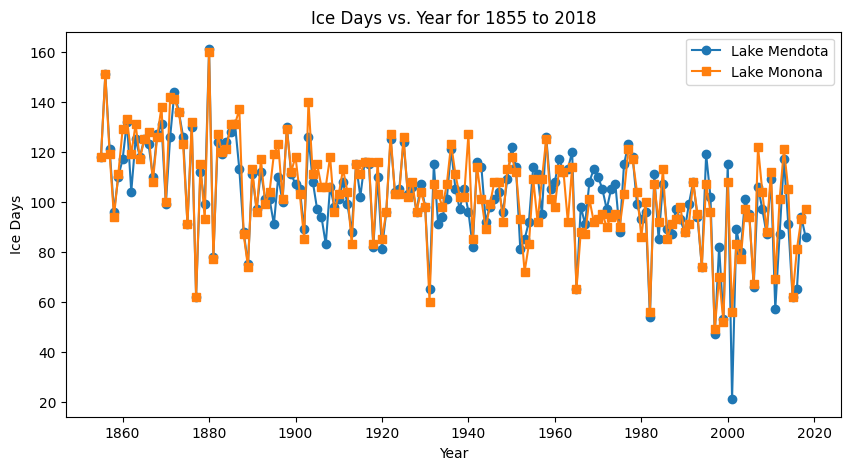

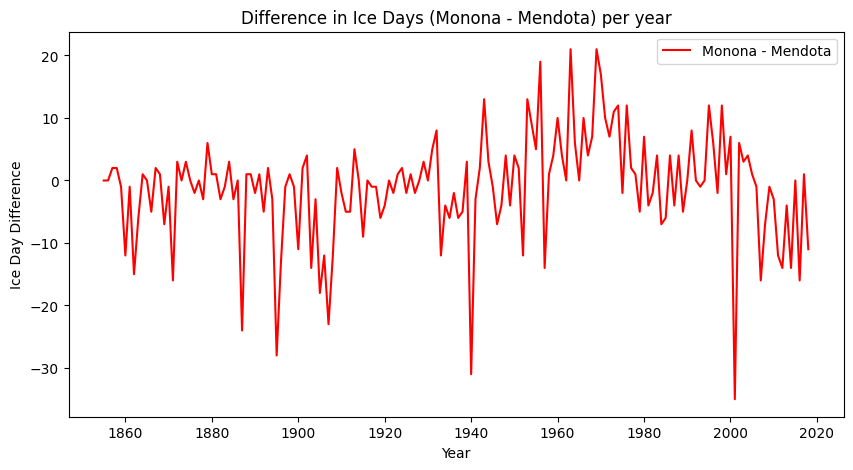

In [ ]:
import matplotlib.pyplot as plt
import csv
import numpy as np
from google.colab import drive
!pip install gdown  # Install gdown if not installed
import gdown


def clean_data(file_info):
  #function to clean the data and return new datasets

  x_years=[]
  y_iceDays=[]


  with open(file_info,'r') as csvfile:
    reader=csv.reader(csvfile)
    next(reader)
    for row in reader:
      try:
        year=row[0]
        year= int((year.split('-')[0])) #get the year info out
        ice_day=int(row[3] )
        if (year>=1855 and year <=2018):
          x_years.append(year)
          y_iceDays.append(ice_day)
      except ValueError:
        continue                        #skip empty rows with wrong info

  return np.array(x_years),np.array(y_iceDays)


#downloading files directly and working on them-i couldnt get them to work with the direct link
file_id_mendota='1ZRlos_kkf7vi82mIvserTwyCzQ_iVHgB'
file_name_mendota="mendota.csv"
gdown.download(f"https://drive.google.com/uc?id={file_id_mendota}",file_name_mendota, quiet=False)
mendota_years, mendota_iceDays= clean_data(file_name_mendota)

file_id_monona='1fAnOXzxQoaL84MMwgdbeBqQmKS89cxfX'
file_name_monona="monona.csv"
gdown.download(f"https://drive.google.com/uc?id={file_id_monona}",file_name_monona, quiet=False)
monona_years, monona_iceDays= clean_data(file_name_monona)

plt.figure(figsize=(10,5))
plt.plot(mendota_years, mendota_iceDays, label='Lake Mendota', marker='o', linestyle='-')
plt.plot(monona_years, monona_iceDays, label='Lake Monona', marker='s', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Ice Days')
plt.legend()
plt.title('Ice Days vs. Year for 1855 to 2018')
plt.show()


differences_iceDays=mendota_iceDays-monona_iceDays
plt.figure(figsize=(10, 5))
plt.plot(mendota_years, differences_iceDays, label='Monona - Mendota', color='red')
plt.xlabel('Year')
plt.ylabel('Ice Day Difference')
plt.title('Difference in Ice Days (Monona - Mendota) per year')
plt.legend()
plt.show()








In [ ]:
#splitting the datasets
training_index= mendota_years<=1970
testing_index=mendota_years>1970

#training set
X_training= mendota_years[training_index]
Y_training_mendota= mendota_iceDays[training_index]
Y_training_monona= monona_iceDays[training_index]

#testing set
X_testing= mendota_years[testing_index]
Y_testing_mendota= mendota_iceDays[testing_index]
Y_testing_monona= monona_iceDays[testing_index]

#computing mean and std deviation

mean_mendota = np.mean(Y_training_mendota)
std_mendota = np.std(Y_training_mendota, ddof=1)

mean_monona = np.mean(Y_training_monona)
std_monona = np.std(Y_training_monona, ddof=1)

print(f"Lake Mendota - Mean: {mean_mendota}, Std Dev: {std_mendota}")
print(f"Lake Monona - Mean: {mean_monona}, Std Dev: {std_monona}")



Lake Mendota - Mean: 107.1896551724138, Std Dev: 16.74666159754441
Lake Monona - Mean: 108.48275862068965, Std Dev: 18.122521543826256


In [ ]:
#OLS Regression

OLS_Z= np.column_stack((np.ones_like(X_training), X_training, Y_training_monona)) #training using given formula
OLS_Y= Y_training_mendota

Z_transpose_Z=np.dot(OLS_Z.T, OLS_Z)
Z_transpose_Y=np.dot(OLS_Z.T, OLS_Y) #computing dot products
beta= np.linalg.inv(Z_transpose_Z).dot(Z_transpose_Y) #computing inverse and then dot product
b0, b1, b2 = beta
print(f"b0: {b0:.4f}, b1: {b1:.4f}, b2: {b2:.4f}") #printing out coefficients



b0: -64.1828, b1: 0.0412, b2: 0.8530


In [ ]:
#computing MSE
#first, we use our test data

OLS_Z_test= np.column_stack((np.ones_like(X_testing), X_testing, Y_testing_monona))
OLS_Y_test= Y_testing_mendota

predicted_coeff= OLS_Z_test @ beta #dot product

computed_diff= np.mean((predicted_coeff - OLS_Y_test)**2)
print(f"Computed MSE: {computed_diff}")
computed_diff_sqrt= np.sqrt(computed_diff)    #makes more sense in context
print(f"Computed RMSE -ice days your prediction is off by on average :{computed_diff_sqrt} days")


Computed MSE: 124.26409483943485
Computed RMSE -ice days your prediction is off by on average :11.14738062683045 days


In [ ]:
#without monona

gamma_train=np.column_stack((np.ones_like(X_training), X_training))       #training
gamma_test=np.column_stack((np.ones_like(X_testing), X_testing))          #testing

#calculating coeff

gamma_transpose_gamma=np.dot(gamma_train.T, gamma_train)    #computing dot products
gamma_transpose_Y=np.dot(gamma_train.T, Y_training_mendota)
beta_gamma= np.linalg.inv(gamma_transpose_gamma).dot(gamma_transpose_Y)
gamma0, gamma1= beta_gamma
print(f"gamma0: {gamma0:.4f}, gamma1: {gamma1:.4f}")




gamma0: 406.1111, gamma1: -0.1563
